# 260528 — atomblob vs with density vs merged density λ

Three-way comparison on **the same val sample with the same block mask**:

| Label                | Run                                                            | Input         | Recipe                                                                                                       |
|----------------------|----------------------------------------------------------------|---------------|---------------------------------------------------------------------------------------------------------------|
| **atomblob**         | `260526_atomblob_vit_mae_40m_pretrain`                         | 11 atom ch    | Uniform mask, equal channel weights.                                                                          |
| **with density**     | `260526_atomblob_density_vit_mae_40m_pretrain`                 | 12 ch (+xray) | Uniform mask, equal channel weights — density dominated ~93% of the loss.                                    |
| **merged density λ** | `260530_atomblob_merged_density_vit_mae_40m_weighted_pretrain` | **8 ch (7 merged atoms + xray)** | Pocket C/O/N/S folded into ligand C/O/N/S channels; atom-biased mask + inv-sqrt-freq atom weights + density_channel_weight=0.1. |

All three runs trained on the same X-ray-available CrossDocked subset (`subset_xray_only=True`, n=78428, val=100) → identical val ordering, so `SAMPLE_IDX=k` resolves to the same ligand–pocket pair for all three. The `merged density λ` checkpoint is read from the rolling `checkpoint.pth.tar`, so its epoch reflects the current state of the in-flight run.

**About the merged model**: it has **no lig-vs-pocket distinction** — `merged_C` predicts "is there a C here?" regardless of source. So:
- For Plot 1 (lig-sum / poc-sum slots), the merged column shows the model's **total-atom prediction** (sum across all 7 merged channels). It looks the same in both 1a and 1b because that's all the merged model can produce.
- For Plot 3 per-channel, the merged-model row shows the same tensor in `lig X` and `poc X` columns — by design (merged_X = lig_X = poc_X for X∈{C,O,N,S}). For X∈{F,Cl,P} only the `lig X` column applies (no pocket equivalent).
- For Plot 2 density, the density channel is at index 7 (merged 8-ch layout) instead of 11.

Plots
1. **Ligand-sum / Pocket-sum (atoms)** — GT | masked | atomblob | with density | merged density λ — for x/y/z planes.
2. **Density channel** — GT | masked | with density | merged density λ | (merged density λ err)·mask.
3. **Per-channel atom comparison** — 4 rows × 11 cols.
4. **Histograms** — three-model overlay on masked atoms-present positions; density histogram for the two density-aware models.

Quantitative metrics in cell 7.

In [1]:
# ── imports + paths ─────────────────────────────────────────────
import sys, os
VOX_ROOT = '/home/shpark/prj-denovo/VoxBind'
if VOX_ROOT not in sys.path:
    sys.path.insert(0, VOX_ROOT)

import numpy as np
import torch
import matplotlib.pyplot as plt
from omegaconf import OmegaConf

from voxbind.models.density_vit import DensityViTMAE
from voxbind.dataset.crossdocked_xray import DatasetCrossDockedXray
from voxbind.voxelizer import Voxelizer
from voxbind.constants import ELEMENTS_HASH_CROSSDOCKED

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
torch.set_grad_enabled(False)
print('device:', device)

device: cuda:0


In [2]:
# ── knobs ───────────────────────────────────────────────────────
from pathlib import Path as _P

EXP_ATOM   = f'{VOX_ROOT}/voxbind/exps/260526_atomblob_vit_mae_40m_pretrain'
EXP_DENS   = f'{VOX_ROOT}/voxbind/exps/260526_atomblob_density_vit_mae_40m_pretrain'
EXP_DENSL  = f'{VOX_ROOT}/voxbind/exps/260530_atomblob_merged_density_vit_mae_40m_weighted_pretrain'  # merged-7 + density

# Resolve the most-recent checkpoint per experiment.
#   `checkpoint.pth.tar`           — rolling, refreshed every `val_every` epoch by the training loop.
#                                    For an in-flight run, this is the freshest state available; for a
#                                    completed run it equals the final numbered checkpoint.
#   `checkpoint_e{NNNN}.pth.tar`   — fixed snapshots saved every `ckpt_every` (=20) epochs.
# Prefer the rolling file when present; fall back to the highest-epoch numbered snapshot.
def latest_ckpt(exp_dir):
    rolling = _P(exp_dir) / 'checkpoint.pth.tar'
    if rolling.exists():
        return str(rolling)
    numbered = sorted(_P(exp_dir).glob('checkpoint_e*.pth.tar'))
    if numbered:
        return str(numbered[-1])
    raise FileNotFoundError(f'no checkpoint found under {exp_dir}')

CKPT_ATOM  = latest_ckpt(EXP_ATOM)
CKPT_DENS  = latest_ckpt(EXP_DENS)
CKPT_DENSL = latest_ckpt(EXP_DENSL)
print(f'CKPT_ATOM  : {CKPT_ATOM}')
print(f'CKPT_DENS  : {CKPT_DENS}')
print(f'CKPT_DENSL : {CKPT_DENSL}  (in-flight runs use the rolling state)')

DATA_DIR  = f'{VOX_ROOT}/voxbind/dataset/data'
CROPS_DIR = f'{DATA_DIR}/xray_crops_aligned'

# SAMPLE_IDX = 60 — `2vwl_lzh` factor-Xa inhibitor.
# Most rare-element-diverse ligand in the 100-sample val pool: ligand has
# C + O + N + S + F + Cl (3/4 of the rare {S, F, Cl, P} channels present; P
# is absent because the val pool has no sample with S+F+Cl+P co-occurrence).
# Top candidates checked against val ligand `atoms_channel`:
#   idx 60 → S+F+Cl  (best — recommended)
#   idx 88 → S+P     (only val sample with P)
SAMPLE_IDX = 60
SLICE_AXIS = 'z'      # 'x', 'y', or 'z' — for the per-channel grid
SLICE_OFFSET = 0      # offset from grid center (in voxels)
SEED_MASK = 0         # reproducible block mask — same across all three forwards

# Match the training config (all three runs share these MAE knobs)
BLOCK_SIZE = 8
MASK_RATIO = 0.60
RESOLUTION = 0.25     # Å / voxel
GRID_DIM = 64
STRUCT_POS_THRESH = 0.05
print(f'mask: {MASK_RATIO:.2f} of {BLOCK_SIZE}³-voxel blocks zeroed; same mask broadcasts across all input channels for all three models')

CKPT_ATOM  : /home/shpark/prj-denovo/VoxBind/voxbind/exps/260526_atomblob_vit_mae_40m_pretrain/checkpoint.pth.tar
CKPT_DENS  : /home/shpark/prj-denovo/VoxBind/voxbind/exps/260526_atomblob_density_vit_mae_40m_pretrain/checkpoint.pth.tar
CKPT_DENSL : /home/shpark/prj-denovo/VoxBind/voxbind/exps/260530_atomblob_merged_density_vit_mae_40m_weighted_pretrain/checkpoint.pth.tar  (in-flight runs use the rolling state)
mask: 0.60 of 8³-voxel blocks zeroed; same mask broadcasts across all input channels for all three models


In [3]:
# ── load all three models from their checkpoints ───────────────────
def build_model_from_ckpt(ckpt_path):
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    cfg = ckpt['cfg']
    m = DensityViTMAE(
        grid_dim=int(cfg.vox.grid_dim),
        patch_size=int(cfg.model.patch_size),
        n_in_channels=int(cfg.model.n_in_channels),
        n_channels=int(cfg.model.n_channels),
        dim=int(cfg.model.dim),
        depth=int(cfg.model.depth),
        n_heads=int(cfg.model.heads),
        mlp_ratio=int(cfg.model.mlp_ratio),
        dropout=float(cfg.model.dropout),
        n_struct_channels=int(cfg.model.n_struct_channels),
    ).to(device).eval()
    sd = ckpt.get('state_dict_ema', ckpt.get('state_dict'))
    sd = {k.replace('module.', '').replace('_orig_mod.', ''): v for k, v in sd.items()}
    miss, unexp = m.load_state_dict(sd, strict=False)
    assert len(miss) == 0 and len(unexp) == 0, (len(miss), len(unexp))
    return m, ckpt, cfg

m_atom,  ck_atom,  cfg_atom  = build_model_from_ckpt(CKPT_ATOM)
m_dens,  ck_dens,  cfg_dens  = build_model_from_ckpt(CKPT_DENS)
m_densl, ck_densl, cfg_densl = build_model_from_ckpt(CKPT_DENSL)

print(f'atomblob           : epoch {ck_atom.get("epoch")}  | n_in={m_atom.encoder.n_in_channels}   '
      f'| params {sum(p.numel() for p in m_atom.parameters()) / 1e6:.2f}M')
print(f'with density       : epoch {ck_dens.get("epoch")}  | n_in={m_dens.encoder.n_in_channels}   '
      f'| params {sum(p.numel() for p in m_dens.parameters()) / 1e6:.2f}M')
print(f'merged density λ   : epoch {ck_densl.get("epoch")}  | n_in={m_densl.encoder.n_in_channels}   '
      f'| params {sum(p.numel() for p in m_densl.parameters()) / 1e6:.2f}M  '
      f'(in-flight: rolling ckpt; n_in=8 = 7 merged atoms + 1 density)')

atomblob           : epoch 99  | n_in=11   | params 45.19M
with density       : epoch 99  | n_in=12   | params 45.45M
merged density λ   : epoch 99  | n_in=8   | params 44.40M  (in-flight: rolling ckpt; n_in=8 = 7 merged atoms + 1 density)


In [4]:
# ── load + voxelize one val sample (same dataset constructor for all models) ────
# Use DatasetCrossDockedXray with use_xray=True so the +density models get the real
# 2Fo-Fc crop. The atomblob model only consumes the first 11 channels.
dset_val = DatasetCrossDockedXray(
    data_dir=DATA_DIR,
    crops_dir=CROPS_DIR,
    split='val', aug=False, small=False,
    ligand_radius=0.5, pocket_radius=-1,
    use_xray=True,
    normalize=True,
    subset_xray_only=True,
    subset_n=78428,
    subset_val_n=100,
)
print('val set size:', len(dset_val))
sample = dset_val[SAMPLE_IDX]
print('sample id:', sample['ligand']['id'])
print('          ', sample['pocket']['id'])
print(f"xray density: shape={tuple(sample['xray_density'].shape)}  "
      f"mean={sample['xray_density'].mean().item():+.3f}  "
      f"std={sample['xray_density'].std().item():.3f}")

voxelizer = Voxelizer(
    grid_dim=GRID_DIM, resolution=RESOLUTION, cubes_around=8, device=device,
)
lig = {k: sample['ligand'][k].unsqueeze(0).to(device)
       for k in ('coords', 'radius', 'atoms_channel')}
poc = {k: sample['pocket'][k].unsqueeze(0).to(device)
       for k in ('coords', 'radius', 'atoms_channel')}
v_lig = voxelizer(lig, num_channels=7)                                 # (1, 7, G, G, G)
v_poc = voxelizer(poc, num_channels=4)                                 # (1, 4, G, G, G)
d_xray = sample['xray_density'].unsqueeze(0).unsqueeze(0).to(device)   # (1, 1, G, G, G)
print('v_lig:', tuple(v_lig.shape), 'v_poc:', tuple(v_poc.shape), 'd_xray:', tuple(d_xray.shape))

val set size: 100
sample id: FA10_HUMAN_126_476_0/2p94_L_rec_2vwl_lzh_lig_tt_docked_0.sdf
           FA10_HUMAN_126_476_0/2p94_L_rec_2vwl_lzh_lig_tt_docked_0_pocket10.pdb
xray density: shape=(64, 64, 64)  mean=-0.007  std=0.974


v_lig: (1, 7, 64, 64, 64) v_poc: (1, 4, 64, 64, 64) d_xray: (1, 1, 64, 64, 64)


In [5]:
# ── assemble inputs + a single shared block mask ─────────────────────────────
x_atom_clean = torch.cat([v_lig, v_poc], dim=1)                  # (1, 11, G³) — for atomblob
x_full_clean = torch.cat([v_lig, v_poc, d_xray], dim=1)          # (1, 12, G³) — for `with density`

# Merged-7 atoms: pocket C/O/N/S folded into ligand C/O/N/S; F/Cl/P stay lig-only.
v_merged = v_lig.clone()
v_merged[:, :4] = v_merged[:, :4] + v_poc                        # (1, 7, G³)
x_merged_clean = torch.cat([v_merged, d_xray], dim=1)            # (1, 8, G³) — for `merged density λ`

# One mask, identical voxel positions for all three forwards.
g_mask = torch.Generator(device=device).manual_seed(SEED_MASK)
B, G = 1, GRID_DIM
blocks = torch.rand(B, 1, G // BLOCK_SIZE, G // BLOCK_SIZE, G // BLOCK_SIZE,
                    device=device, generator=g_mask) < MASK_RATIO
mask = blocks.repeat_interleave(BLOCK_SIZE, 2)\
             .repeat_interleave(BLOCK_SIZE, 3)\
             .repeat_interleave(BLOCK_SIZE, 4)                    # (1, 1, G, G, G)

x_atom_in   = x_atom_clean   * (~mask).to(x_atom_clean.dtype)     # (1, 11, G³)
x_full_in   = x_full_clean   * (~mask).to(x_full_clean.dtype)     # (1, 12, G³)
x_merged_in = x_merged_clean * (~mask).to(x_merged_clean.dtype)   # (1,  8, G³)

print(f'mask fraction (voxel): {mask.float().mean().item():.3f}  (target {MASK_RATIO})')
n_blocks = (GRID_DIM // BLOCK_SIZE) ** 3
print(f'masked blocks: {blocks.sum().item()}/{n_blocks}')
print(f'x_atom_clean   : {tuple(x_atom_clean.shape)}    (lig 0:7  + poc 7:11)')
print(f'x_full_clean   : {tuple(x_full_clean.shape)}    (atoms 0:11 + density 11)')
print(f'x_merged_clean : {tuple(x_merged_clean.shape)}     (merged atoms 0:7 + density 7)')

mask fraction (voxel): 0.580  (target 0.6)
masked blocks: 297/512
x_atom_clean   : (1, 11, 64, 64, 64)    (lig 0:7  + poc 7:11)
x_full_clean   : (1, 12, 64, 64, 64)    (atoms 0:11 + density 11)
x_merged_clean : (1, 8, 64, 64, 64)     (merged atoms 0:7 + density 7)


In [6]:
# ── forward all three models on their respective inputs ──────────────────
out_atom,  _ = m_atom(x_atom_in)                                 # (1, 11, G³)
out_dens,  _ = m_dens(x_full_in)                                 # (1, 12, G³); density at idx 11
out_densl, _ = m_densl(x_merged_in)                              # (1,  8, G³); density at idx 7
print('atomblob          output:', tuple(out_atom.shape))
print('with density      output:', tuple(out_dens.shape),  '  (last channel = density)')
print('merged density λ  output:', tuple(out_densl.shape), '  (atoms 0:7, density 7)')

atomblob          output: (1, 11, 64, 64, 64)
with density      output: (1, 12, 64, 64, 64)   (last channel = density)
merged density λ  output: (1, 8, 64, 64, 64)   (atoms 0:7, density 7)


In [7]:
# ── side-by-side metrics ───────────────────────────────────────────────────
# atomblob + with density are reported on the 11-channel target (lig 0:7, poc 7:11).
# merged density λ is reported on the 7-channel merged target so the metric is
# defined for its actual output. Atom-level numbers across models share the same
# atom-mass interpretation (sum of atoms per voxel).
def report_atom_metrics_11ch(name, out_atoms_11, x_full_clean, mask):
    m = mask.to(out_atoms_11.dtype)
    n_spatial = m.sum().clamp(min=1.0)
    diff_sq = (out_atoms_11 - x_full_clean[:, :11]) ** 2 * m
    L = diff_sq.sum() / (n_spatial * 11)
    print(f'\n[{name}] L_recon (atoms, masked, mean over 11 ch): {L.item():.5f}')
    for src_name, sl in [('lig', slice(None, 7)), ('poc', slice(7, 11))]:
        tgt  = x_full_clean[0, sl]
        pred = out_atoms_11[0, sl]
        pos = tgt > STRUCT_POS_THRESH
        pos_frac = pos.float().mean().item()
        mse_on  = ((pred[pos]  - tgt[pos])  ** 2).mean().item() if pos.any() else float('nan')
        mse_off = ((pred[~pos] - tgt[~pos]) ** 2).mean().item()
        m_bool = mask[0, 0].bool()
        tgt_m, pred_m = tgt[:, m_bool], pred[:, m_bool]
        pos_m = tgt_m > STRUCT_POS_THRESH
        m_on  = ((pred_m[pos_m]  - tgt_m[pos_m])  ** 2).mean().item() if pos_m.any() else float('nan')
        m_off = ((pred_m[~pos_m] - tgt_m[~pos_m]) ** 2).mean().item()
        print(f'  {src_name}: pos-frac={pos_frac:.4f}  peak tgt={tgt.max().item():.3f} pred={pred.max().item():.3f}  '
              f'MSE@on={mse_on:.4f} MSE@off={mse_off:.6f}  |  masked@on={m_on:.4f} masked@off={m_off:.6f}')

def report_atom_metrics_merged7(name, out_atoms_7, x_merged_clean, mask):
    m = mask.to(out_atoms_7.dtype)
    n_spatial = m.sum().clamp(min=1.0)
    diff_sq = (out_atoms_7 - x_merged_clean[:, :7]) ** 2 * m
    L = diff_sq.sum() / (n_spatial * 7)
    print(f'\n[{name}] L_recon (merged atoms, masked, mean over 7 ch): {L.item():.5f}')
    # Two sub-views: (a) common elements C/O/N/S (channels 0..3, pocket+ligand),
    # (b) rare lig-only elements F/Cl/P (channels 4..6, no pocket equivalent).
    for src_name, sl in [('CONS', slice(None, 4)), ('FClP', slice(4, 7))]:
        tgt  = x_merged_clean[0, sl]
        pred = out_atoms_7[0, sl]
        pos = tgt > STRUCT_POS_THRESH
        pos_frac = pos.float().mean().item()
        mse_on  = ((pred[pos]  - tgt[pos])  ** 2).mean().item() if pos.any() else float('nan')
        mse_off = ((pred[~pos] - tgt[~pos]) ** 2).mean().item()
        m_bool = mask[0, 0].bool()
        tgt_m, pred_m = tgt[:, m_bool], pred[:, m_bool]
        pos_m = tgt_m > STRUCT_POS_THRESH
        m_on  = ((pred_m[pos_m]  - tgt_m[pos_m])  ** 2).mean().item() if pos_m.any() else float('nan')
        m_off = ((pred_m[~pos_m] - tgt_m[~pos_m]) ** 2).mean().item()
        print(f'  {src_name}: pos-frac={pos_frac:.4f}  peak tgt={tgt.max().item():.3f} pred={pred.max().item():.3f}  '
              f'MSE@on={mse_on:.4f} MSE@off={mse_off:.6f}  |  masked@on={m_on:.4f} masked@off={m_off:.6f}')

report_atom_metrics_11ch('atomblob       ', out_atom,          x_full_clean, mask)
report_atom_metrics_11ch('with density   ', out_dens[:, :11],  x_full_clean, mask)
report_atom_metrics_merged7('merged density λ', out_densl[:, :7], x_merged_clean, mask)

# density-only metrics for the two +density models (channel index differs!)
dens_tgt = x_full_clean[0, 11]
m_bool = mask[0, 0].bool()
high = dens_tgt > 1.0
print(f'\n[density channel summary]  range tgt=[{dens_tgt.min().item():+.2f},{dens_tgt.max().item():+.2f}]')
for name, out_full, dens_idx in [
    ('with density   ',  out_dens,  11),
    ('merged density λ', out_densl,  7),
]:
    dens_prd = out_full[0, dens_idx]
    print(f'  [{name}] pred=[{dens_prd.min().item():+.2f},{dens_prd.max().item():+.2f}]  '
          f'MSE@all={((dens_prd-dens_tgt)**2).mean().item():.4f}'
          f"  MSE@>1σ={((dens_prd[high]-dens_tgt[high])**2).mean().item():.4f}"
          f"  MSE@masked={((dens_prd[m_bool]-dens_tgt[m_bool])**2).mean().item():.4f}")


[atomblob       ] L_recon (atoms, masked, mean over 11 ch): 0.00016
  lig: pos-frac=0.0026  peak tgt=0.991 pred=1.048  MSE@on=0.0146 MSE@off=0.000005  |  masked@on=0.0150 masked@off=0.000007
  poc: pos-frac=0.2655  peak tgt=1.000 pred=1.029  MSE@on=0.0008 MSE@off=0.000064  |  masked@on=0.0011 masked@off=0.000080

[with density   ] L_recon (atoms, masked, mean over 11 ch): 0.00042
  lig: pos-frac=0.0026  peak tgt=0.991 pred=0.394  MSE@on=0.0629 MSE@off=0.000023  |  masked@on=0.0683 masked@off=0.000019
  poc: pos-frac=0.2655  peak tgt=1.000 pred=1.053  MSE@on=0.0023 MSE@off=0.000236  |  masked@on=0.0025 masked@off=0.000230

[merged density λ] L_recon (merged atoms, masked, mean over 7 ch): 0.00099
  CONS: pos-frac=0.2699  peak tgt=1.000 pred=1.115  MSE@on=0.0035 MSE@off=0.000868  |  masked@on=0.0038 masked@off=0.000898
  FClP: pos-frac=0.0004  peak tgt=0.959 pred=0.001  MSE@on=0.0904 MSE@off=0.000000  |  masked@on=0.0861 masked@off=0.000000

[density channel summary]  range tgt=[-2.75,+

In [8]:
# ── slicing helpers ─────────────────────────────────────────────────
def take_slice(vol, axis='z', offset=0):
    arr = vol.detach().cpu().numpy() if torch.is_tensor(vol) else vol
    G = arr.shape[-1]
    idx = G // 2 + offset
    if axis == 'x':
        return arr[idx, :, :]
    elif axis == 'y':
        return arr[:, idx, :]
    elif axis == 'z':
        return arr[:, :, idx]
    raise ValueError(axis)

def show(ax, img, title, cmap='gray', vmin=None, vmax=None):
    im = ax.imshow(img.T, origin='lower', cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title, fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
    return im

## Plot 1 — atom channels: ligand-sum and pocket-sum, three models side-by-side

Columns: GT | masked input | **atomblob** | **with density** | **merged density λ**.

The merged column shows the **total-atom prediction** (sum across all 7 merged channels) — it's the same content in both 1a and 1b because the merged model can't separate lig from poc.

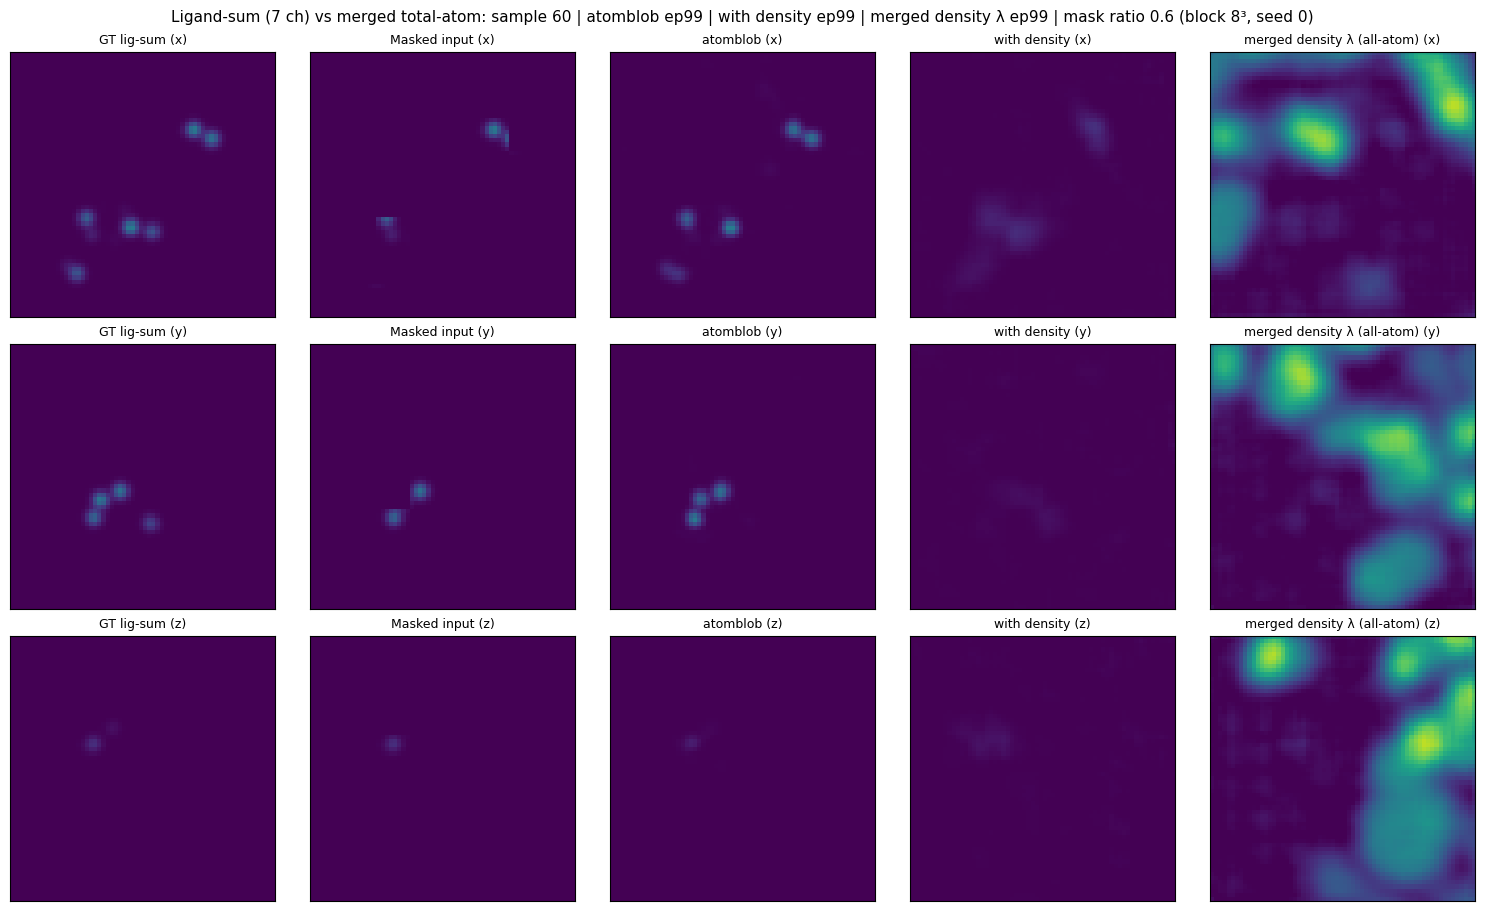

In [9]:
# ── plot 1a: ligand-sum (7 ch) — atomblob/with density show lig 0:7;
#    merged shows all-7 merged channels (no lig/poc separation possible) ───────
mask_3d = mask[0, 0]
tgt_lig    = x_full_clean[0, :7].sum(0)
in_lig     = (x_full_clean[0, :7] * (~mask_3d.bool()).float()).sum(0)
pred_lig_a = out_atom[0, :7].sum(0)
pred_lig_d = out_dens[0, :7].sum(0)
pred_merg  = out_densl[0, :7].sum(0)                  # merged total atom prediction

vmax_lig = max(tgt_lig.max().item(), pred_lig_a.max().item(),
               pred_lig_d.max().item(), pred_merg.max().item(), 1e-3)

fig, axes = plt.subplots(3, 5, figsize=(15, 9), constrained_layout=True)
for i, ax_name in enumerate(['x', 'y', 'z']):
    show(axes[i, 0], take_slice(tgt_lig, ax_name, SLICE_OFFSET),
         f'GT lig-sum ({ax_name})',         cmap='viridis', vmin=0, vmax=vmax_lig)
    show(axes[i, 1], take_slice(in_lig, ax_name, SLICE_OFFSET),
         f'Masked input ({ax_name})',       cmap='viridis', vmin=0, vmax=vmax_lig)
    show(axes[i, 2], take_slice(pred_lig_a, ax_name, SLICE_OFFSET),
         f'atomblob ({ax_name})',           cmap='viridis', vmin=0, vmax=vmax_lig)
    show(axes[i, 3], take_slice(pred_lig_d, ax_name, SLICE_OFFSET),
         f'with density ({ax_name})',       cmap='viridis', vmin=0, vmax=vmax_lig)
    show(axes[i, 4], take_slice(pred_merg, ax_name, SLICE_OFFSET),
         f'merged density λ (all-atom) ({ax_name})', cmap='viridis', vmin=0, vmax=vmax_lig)
fig.suptitle(
    f"Ligand-sum (7 ch) vs merged total-atom: sample {SAMPLE_IDX} | atomblob ep{ck_atom.get('epoch')} | "
    f"with density ep{ck_dens.get('epoch')} | merged density λ ep{ck_densl.get('epoch')} | "
    f"mask ratio {MASK_RATIO} (block {BLOCK_SIZE}³, seed {SEED_MASK})",
    fontsize=11,
)
plt.show()

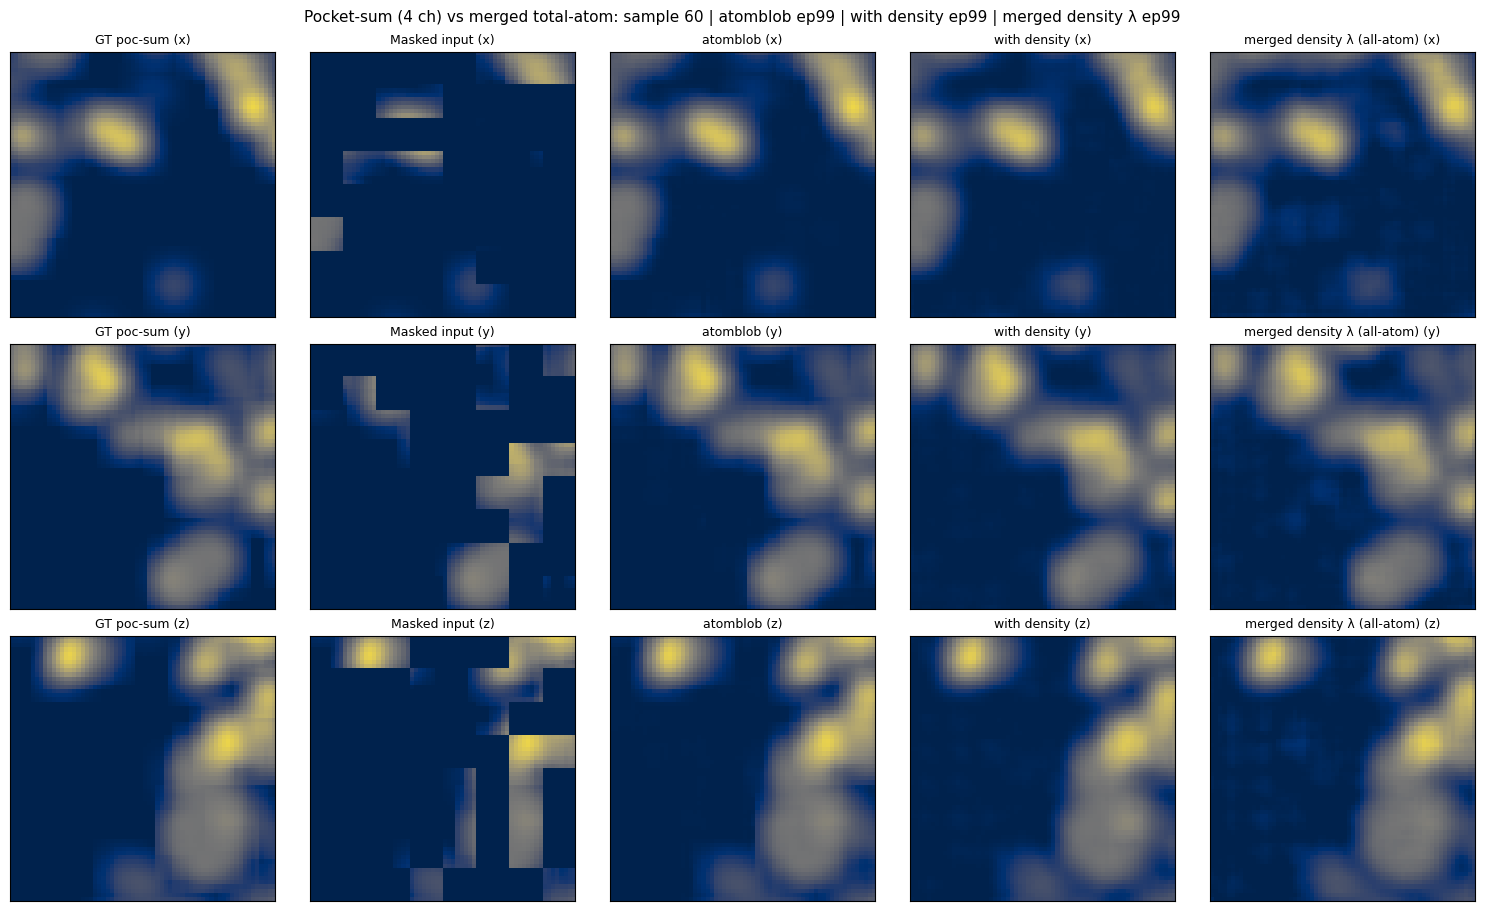

In [10]:
# ── plot 1b: pocket-sum (4 ch) — atomblob/with density show poc 7:11;
#    merged shows all-7 merged channels (same content as 1a's merged col) ──────
tgt_poc    = x_full_clean[0, 7:11].sum(0)
in_poc     = (x_full_clean[0, 7:11] * (~mask_3d.bool()).float()).sum(0)
pred_poc_a = out_atom[0, 7:11].sum(0)
pred_poc_d = out_dens[0, 7:11].sum(0)
pred_merg  = out_densl[0, :7].sum(0)                  # merged total atom prediction (same as 1a)

vmax_poc = max(tgt_poc.max().item(), pred_poc_a.max().item(),
               pred_poc_d.max().item(), pred_merg.max().item(), 1e-3)

fig, axes = plt.subplots(3, 5, figsize=(15, 9), constrained_layout=True)
for i, ax_name in enumerate(['x', 'y', 'z']):
    show(axes[i, 0], take_slice(tgt_poc, ax_name, SLICE_OFFSET),
         f'GT poc-sum ({ax_name})',         cmap='cividis', vmin=0, vmax=vmax_poc)
    show(axes[i, 1], take_slice(in_poc, ax_name, SLICE_OFFSET),
         f'Masked input ({ax_name})',       cmap='cividis', vmin=0, vmax=vmax_poc)
    show(axes[i, 2], take_slice(pred_poc_a, ax_name, SLICE_OFFSET),
         f'atomblob ({ax_name})',           cmap='cividis', vmin=0, vmax=vmax_poc)
    show(axes[i, 3], take_slice(pred_poc_d, ax_name, SLICE_OFFSET),
         f'with density ({ax_name})',       cmap='cividis', vmin=0, vmax=vmax_poc)
    show(axes[i, 4], take_slice(pred_merg, ax_name, SLICE_OFFSET),
         f'merged density λ (all-atom) ({ax_name})', cmap='cividis', vmin=0, vmax=vmax_poc)
fig.suptitle(
    f"Pocket-sum (4 ch) vs merged total-atom: sample {SAMPLE_IDX} | atomblob ep{ck_atom.get('epoch')} | "
    f"with density ep{ck_dens.get('epoch')} | merged density λ ep{ck_densl.get('epoch')}",
    fontsize=11,
)
plt.show()

## Plot 2 — density channel (only the two +density models predict this)

Columns: GT | masked | with density | merged density λ | (merged density λ pred − GT)·mask. The atomblob model has no density channel; the error column shows where the merged-λ model differs from GT. Note the density channel index differs across models (11 for the 12-channel model, 7 for the merged 8-channel model).

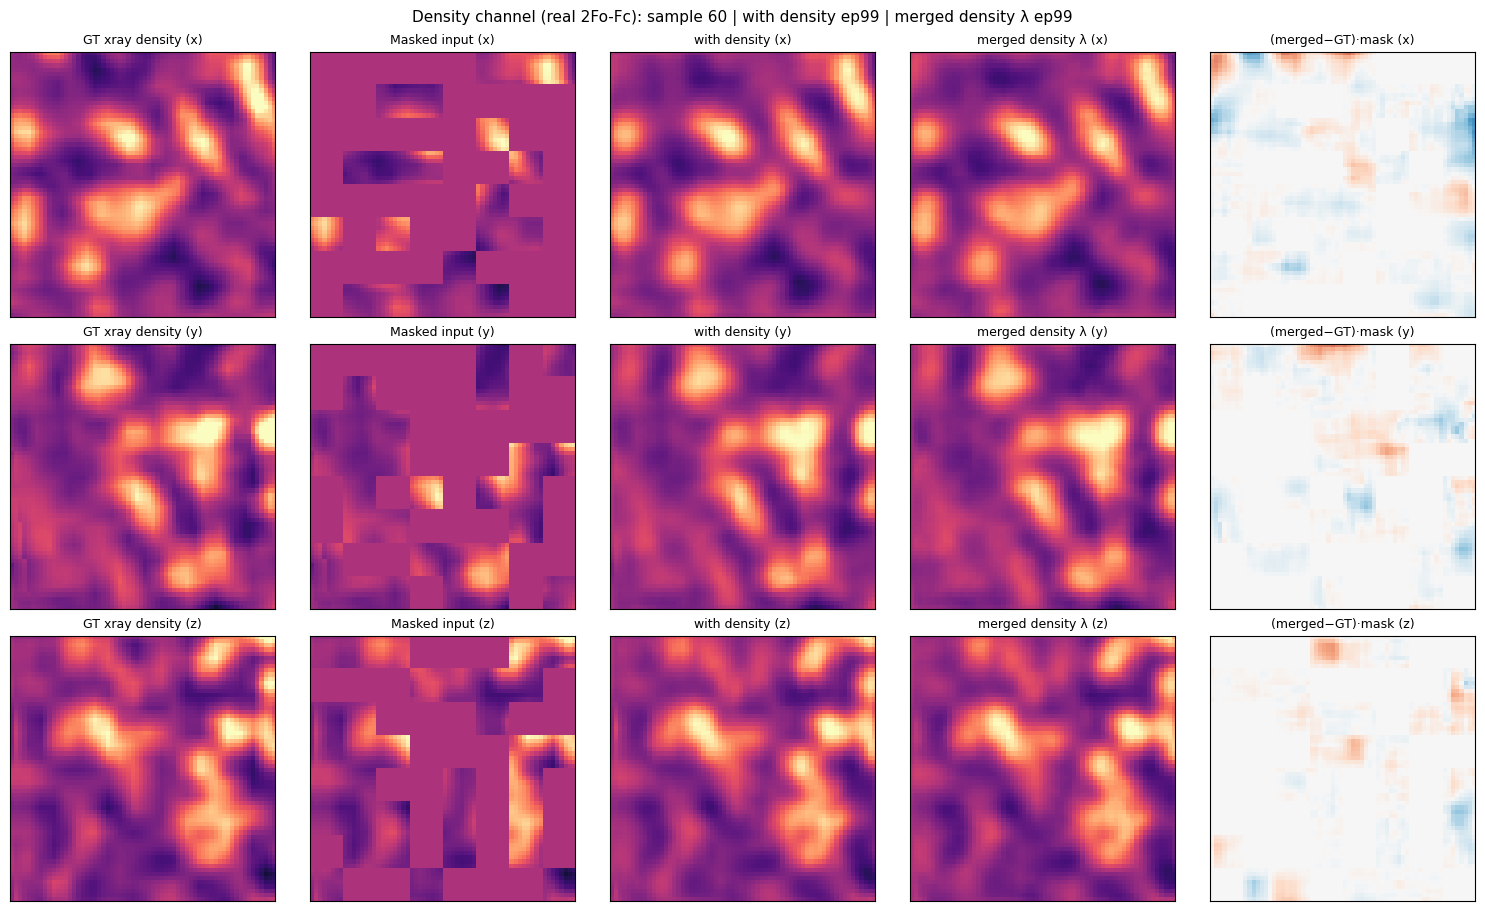

In [11]:
# ── plot 2: density channel — GT | masked | with density | merged density λ | err, x/y/z ──
tgt_dens   = x_full_clean[0, 11]
in_dens    = x_full_clean[0, 11] * (~mask_3d.bool()).float()
pred_dens  = out_dens[0, 11]                       # 12-ch model: density at idx 11
pred_densl = out_densl[0, 7]                       # 8-ch merged model: density at idx 7
err_densl  = (pred_densl - tgt_dens) * mask_3d.float()

vlo = tgt_dens.min().item()
vhi = tgt_dens.max().item()
err_abs = max(err_densl.abs().max().item(), 1e-3)

fig, axes = plt.subplots(3, 5, figsize=(15, 9), constrained_layout=True)
for i, ax_name in enumerate(['x', 'y', 'z']):
    show(axes[i, 0], take_slice(tgt_dens, ax_name, SLICE_OFFSET),
         f'GT xray density ({ax_name})',         cmap='magma', vmin=vlo, vmax=vhi)
    show(axes[i, 1], take_slice(in_dens, ax_name, SLICE_OFFSET),
         f'Masked input ({ax_name})',            cmap='magma', vmin=vlo, vmax=vhi)
    show(axes[i, 2], take_slice(pred_dens, ax_name, SLICE_OFFSET),
         f'with density ({ax_name})',            cmap='magma', vmin=vlo, vmax=vhi)
    show(axes[i, 3], take_slice(pred_densl, ax_name, SLICE_OFFSET),
         f'merged density λ ({ax_name})',        cmap='magma', vmin=vlo, vmax=vhi)
    show(axes[i, 4], take_slice(err_densl, ax_name, SLICE_OFFSET),
         f'(merged−GT)·mask ({ax_name})',        cmap='RdBu_r', vmin=-err_abs, vmax=err_abs)
fig.suptitle(
    f"Density channel (real 2Fo-Fc): sample {SAMPLE_IDX} | "
    f"with density ep{ck_dens.get('epoch')} | merged density λ ep{ck_densl.get('epoch')}",
    fontsize=11,
)
plt.show()

## Plot 3 — per-channel atom comparison

4 rows × 11 cols on `SLICE_AXIS`. Row 0 = target, row 1 = atomblob pred, row 2 = with density pred, row 3 = merged density λ pred.

For the merged-model row (3):
- Cols 0–6 (lig C/O/N/S/F/Cl/P): show the corresponding `out_densl[c]` (the merged element-c prediction).
- Cols 7–10 (poc C/O/N/S): show the **same** `out_densl[c-7]` tensor — by design, merged_C is the prediction for *all C atoms regardless of source*, so poc-C and lig-C land on the same channel. Cols 0+7, 1+8, 2+9, 3+10 should be visually identical.

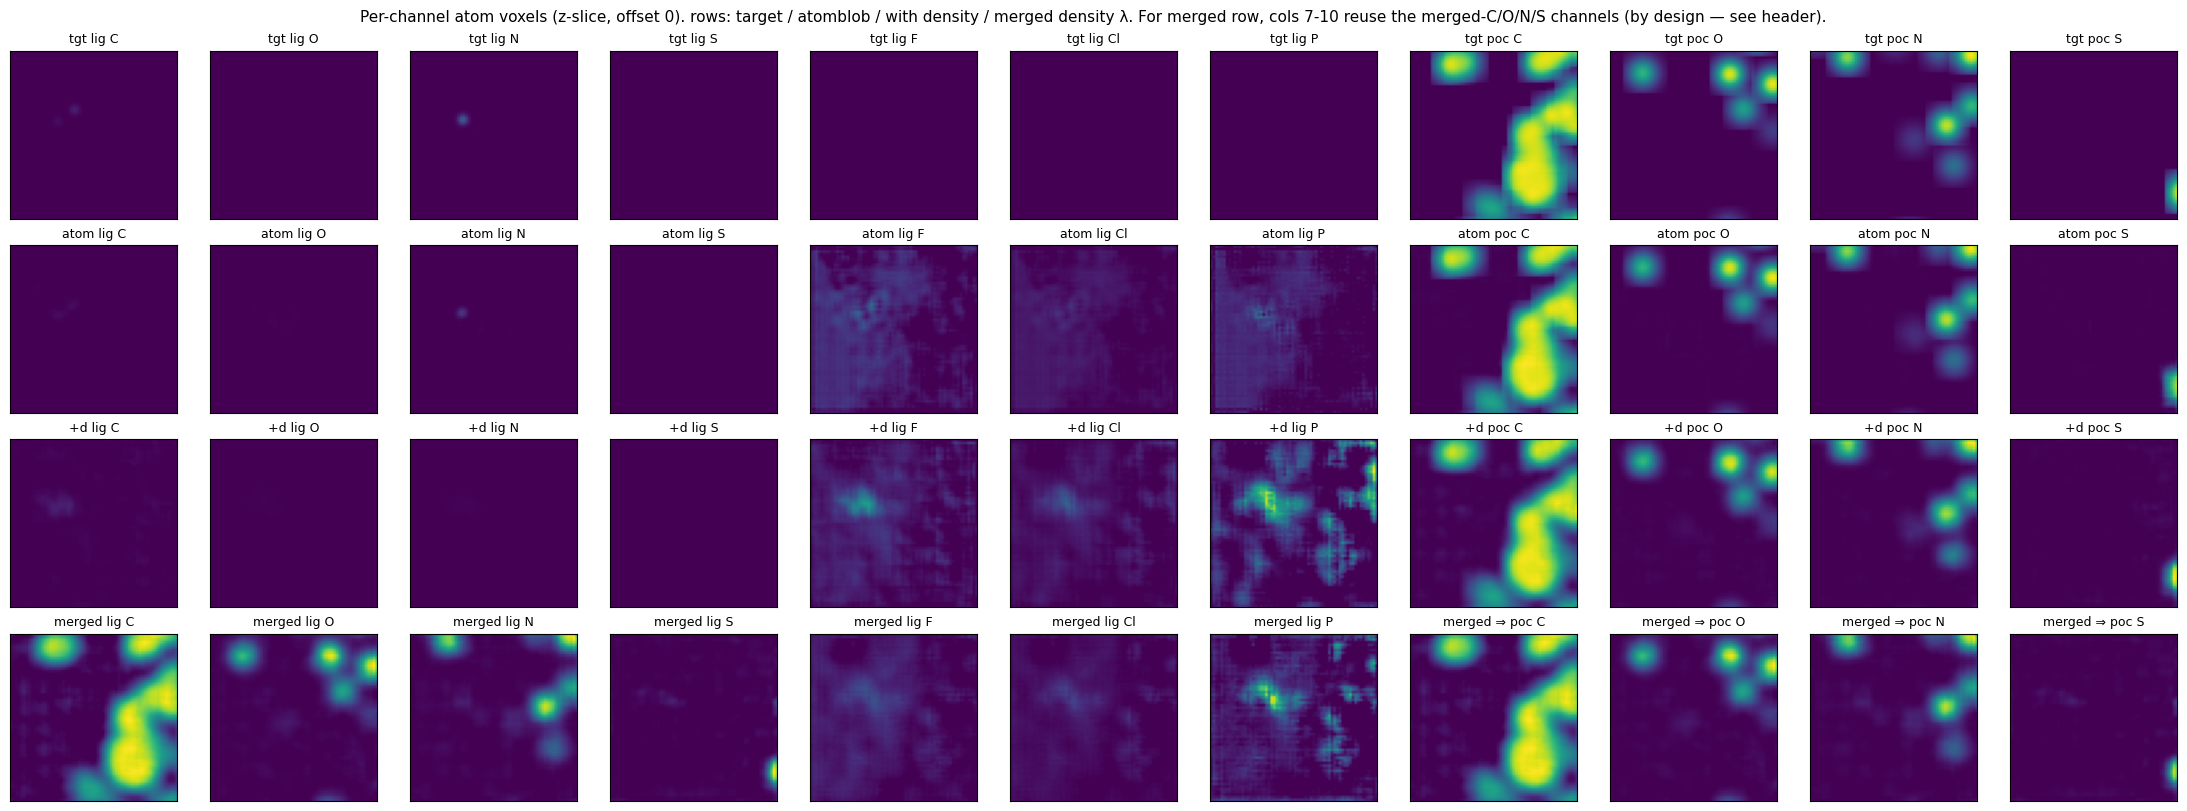

In [12]:
# ── per-channel grid: 4 rows × 11 cols (target / atomblob / with density / merged density λ) ─
elem_names = list(ELEMENTS_HASH_CROSSDOCKED.keys())
lig_names = [f'lig {elem_names[i]}' for i in range(7)]
poc_names = [f'poc {elem_names[i]}' for i in range(4)]
chan_names = lig_names + poc_names

# Map per-output-channel for the merged model: cols 0-6 → out_densl[c]; cols 7-10 → out_densl[c-7].
def merged_channel_for_col(c):
    return c if c < 7 else c - 7

fig, axes = plt.subplots(4, 11, figsize=(22, 8.0), constrained_layout=True)
for c in range(11):
    tgt = take_slice(x_full_clean[0, c], SLICE_AXIS, SLICE_OFFSET)
    p_a = take_slice(out_atom[0, c],     SLICE_AXIS, SLICE_OFFSET)
    p_d = take_slice(out_dens[0, c],     SLICE_AXIS, SLICE_OFFSET)
    p_l = take_slice(out_densl[0, merged_channel_for_col(c)], SLICE_AXIS, SLICE_OFFSET)
    vmax = max(float(tgt.max()), float(p_a.max()), float(p_d.max()), float(p_l.max()), 1e-3)
    show(axes[0, c], tgt, f'tgt {chan_names[c]}',     cmap='viridis', vmin=0, vmax=vmax)
    show(axes[1, c], p_a, f'atom {chan_names[c]}',    cmap='viridis', vmin=0, vmax=vmax)
    show(axes[2, c], p_d, f'+d {chan_names[c]}',      cmap='viridis', vmin=0, vmax=vmax)
    label_l = f'merged {chan_names[c]}' if c < 7 else f'merged ⇒ {chan_names[c]}'
    show(axes[3, c], p_l, label_l,                    cmap='viridis', vmin=0, vmax=vmax)
fig.suptitle(
    f'Per-channel atom voxels ({SLICE_AXIS}-slice, offset {SLICE_OFFSET}). '
    f'rows: target / atomblob / with density / merged density λ. '
    f'For merged row, cols 7-10 reuse the merged-C/O/N/S channels (by design — see header).',
    fontsize=11,
)
plt.show()

## Plot 4 — histograms on masked positions

Atom histograms (per source) overlay all three models' predicted distributions against the target distribution on masked atoms-present voxels. For the merged model on the per-source histograms, we use the merged-element channels (e.g. for the `lig` histogram, we map lig-C → merged_C, lig-O → merged_O, …). Density histogram shows the two +density models' predictions on masked voxels.

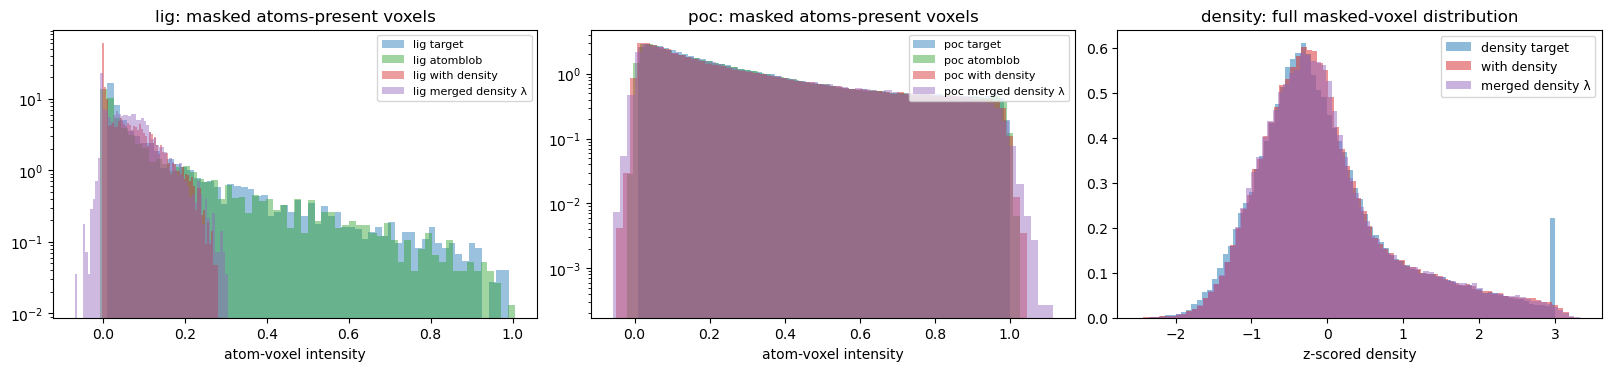

In [13]:
# ── histograms: target | three model predictions — on masked atoms-present voxels ──
fig, axes = plt.subplots(1, 3, figsize=(16, 3.6), constrained_layout=True)

m_bool_flat = mask[0, 0].bool().flatten().cpu()
# For each per-source histogram, we need to index out_densl by the appropriate merged channel:
#   lig channels 0..6 → merged channels 0..6 (identity)
#   poc channels 7..10 → merged channels 0..3 (C/O/N/S)
for ax, (name, src_slice, merged_idx) in zip(
    axes[:2],
    [('lig', slice(None, 7), torch.arange(0, 7)),
     ('poc', slice(7, 11),   torch.arange(0, 4))],
):
    tgt_full = x_full_clean[0, src_slice]
    pa_full  = out_atom[0, src_slice]
    pd_full  = out_dens[0, src_slice]
    pl_full  = out_densl[0, merged_idx]              # picks merged channels per source
    tgt_flat = tgt_full.flatten(1).cpu()[:, m_bool_flat].flatten().numpy()
    pa_flat  = pa_full.flatten(1).cpu()[:, m_bool_flat].flatten().numpy()
    pd_flat  = pd_full.flatten(1).cpu()[:, m_bool_flat].flatten().numpy()
    pl_flat  = pl_full.flatten(1).cpu()[:, m_bool_flat].flatten().numpy()
    sel = tgt_flat > 0.01
    if sel.any():
        # selection has shape matching tgt_flat; for the merged channel mapping the lengths
        # match because the spatial dim is the same; only the channel count differs.
        ax.hist(tgt_flat[sel], bins=60, alpha=0.45, color='C0', density=True, label=f'{name} target')
        ax.hist(pa_flat[sel], bins=60, alpha=0.45, color='C2', density=True, label=f'{name} atomblob')
        ax.hist(pd_flat[sel], bins=60, alpha=0.45, color='C3', density=True, label=f'{name} with density')
        # For merged, the prediction tensor has fewer entries when name=='poc' (4 ch vs 4 ch ok;
        # for name=='lig' the merged tensor has 7 ch matching the lig slice). So pl_flat[sel] is
        # only meaningful when len(pl_flat) == len(tgt_flat). When they match we plot it; else fall
        # back to plotting the merged channels independently.
        if pl_flat.shape == tgt_flat.shape:
            ax.hist(pl_flat[sel], bins=60, alpha=0.45, color='C4', density=True, label=f'{name} merged density λ')
        else:
            sel_l = pl_flat > -1e9       # take all merged-channel positions (no target filter possible here)
            ax.hist(pl_flat[sel_l],      bins=60, alpha=0.30, color='C4', density=True, label=f'{name} merged density λ (all)')
    ax.set_yscale('log')
    ax.set_xlabel('atom-voxel intensity')
    ax.legend(fontsize=8)
    ax.set_title(f'{name}: masked atoms-present voxels')

# density: two +density models vs target (different indices!)
tgt_d_flat  = x_full_clean[0, 11].flatten().cpu()[m_bool_flat].numpy()
pred_d_flat = out_dens[0, 11].flatten().cpu()[m_bool_flat].numpy()
pred_l_flat = out_densl[0, 7].flatten().cpu()[m_bool_flat].numpy()
axes[2].hist(tgt_d_flat,  bins=80, alpha=0.5, color='C0', density=True, label='density target')
axes[2].hist(pred_d_flat, bins=80, alpha=0.5, color='C3', density=True, label='with density')
axes[2].hist(pred_l_flat, bins=80, alpha=0.5, color='C4', density=True, label='merged density λ')
axes[2].set_xlabel('z-scored density')
axes[2].legend(fontsize=9)
axes[2].set_title('density: full masked-voxel distribution')
plt.show()

## Notes

* `atomblob` and `with density` checkpoints are final (epoch 99). `merged density λ` checkpoint is read from the rolling `checkpoint.pth.tar` of the in-flight run — `ck_densl['epoch']` reports its current epoch. Re-run cell 3 to refresh once new epochs land.
* All three models share the same encoder size (40M-param ViT-MAE, dim=512, depth=12, heads=8) and were trained on the same X-ray-available CrossDocked subset. The merged model has ~44.4M params (slightly fewer due to the narrower 8-ch patch embed).
* `SEED_MASK=0` → identical voxel-level masked positions for all three forwards. Differences in Plot 1 / Plot 3 are pure architecture/training effects, not mask noise.
* `n_struct_channels=0` in all three runs → `a_hat is None`; pretext output is the direct per-channel reconstruction.
* **Loss reporting**: atomblob and `with density` are reported on the 11-channel target (lig 0:7, poc 7:11); merged density λ is reported on the 7-channel merged target. The L_recon numbers are therefore NOT directly comparable between groups — but per-source MSE@on/off (within atoms-present voxels) is interpretable across all three.
* **merged density λ recipe**: pocket C/O/N/S folded into ligand C/O/N/S channels (lig-vs-pocket disambiguation removed); atom-biased block mask + inv-sqrt-freq atom-channel weighting on the 7 merged channels + `density_channel_weight=0.1` (renormalized so the 8-vec sums to 8). This addresses three failure modes at once:
  - **Sparsity within atom channels** — rare elements (lig F/Cl/P) heavily up-weighted.
  - **Density gradient hog** — density channel weighted ~0.11 instead of 1.0.
  - **Lig-vs-pocket disambiguation hardness** — eliminated by channel merge.
* Expected behavior on Plot 3: row 3 cols 0+7 / 1+8 / 2+9 / 3+10 should be visually identical (merged_C/O/N/S used for both lig and poc target columns). Cols 4/5/6 (F/Cl/P) only have meaningful lig content; the model still has to recover these from sparse rare-element signal even with weighting.